In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from tabulate import tabulate
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

#import nltk
#nltk.download('stopwords')
from nltk.corpus import stopwords

Chargement des données

In [11]:
movies = pd.read_csv('ratings_preprocessed.csv')
tagsMovie = pd.read_csv('tags_preprocessed.csv')
genomeMovie = pd.read_csv('genome_scores_preprocessed.csv')

	
Filtrage basé sur le contenu : on utilise l'information qu'on connaît sur les intérêts des utilisateurs comme liaison pour les recommandations potentielles. Ces intérêts sont dans le dataframe tagsMovie

1ere modèle : on utilise les tags des utilisateurs, et on détermine les films similaires

In [3]:
tagsMovie.head()

,movieId,tag,title,genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,genre_Documentary,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,1,the boys classic pixar Disney pixar cgi animat...,Toy Story (1995),0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,monkey For children game animals kid flick Chi...,Jumanji (1995),0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Funniest Movies sequel fever comedinha de velh...,Grumpier Old Men (1995),0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,chick flick revenge characters characters chic...,Waiting to Exhale (1995),0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,wedding sequel family pregnancy remake sequel ...,Father of the Bride Part II (1995),0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


Nombre de mots dans les tags :  5597533


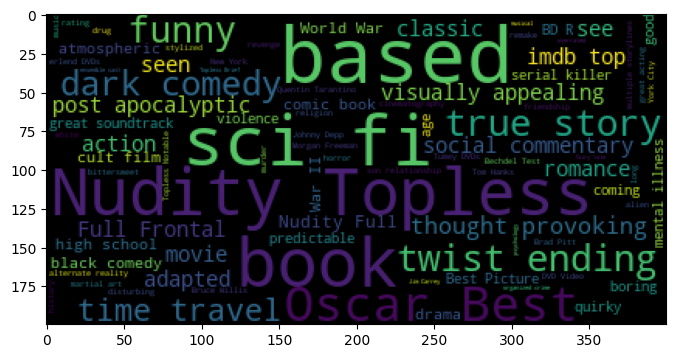

In [4]:
# affichage des mots dominants dans les tags des films

text = ""
for tg in tagsMovie.tag : 
    text += tg

print("Nombre de mots dans les tags : ", len(text))

stop_words = set(stopwords.words('english'))
#stop_words.update([",", ".", ":", "-"])

#tokens = [mot for mot in text if mot not in stop_words]
#print("Nombre de mots après filtrage : ", len(tokens))

# Définir le calque du nuage des mots
wc = WordCloud(background_color="black", max_words=1000, stopwords=stop_words, max_font_size=50, random_state=42)
# Générer et afficher le nuage de mots
plt.figure(figsize= (8,6)) # Initialisation d'une figure
wc.generate(text)           # "Calcul" du wordcloud
plt.imshow(wc) # Affichage
plt.show()

Il ne semble pas avoir des mots vides

In [5]:
# tokenization et vectorisation des tags
# création d'un TfidfVectorizer et suppression des mots vides
tfidf = TfidfVectorizer(stop_words='english')
# Adapter et transformer les données en une matrice tfidf
matrice_tfidf = tfidf.fit_transform(tagsMovie['tag'])
print(matrice_tfidf.shape)
# on a 19536 films et 23863 mots importants après avoir enlevé les mots vides

# similarité des films
# On calcule la similarité cosinus
sim_cosinus = cosine_similarity(matrice_tfidf, matrice_tfidf)

# On calcule la similarité euclidienne
# On rappelle que dans la mesure euclidienne plus la distance est courte, plus la similitude est élevée. Pour garantir que des valeurs plus élevées correspondent à une plus grande similarité (convention courante dans les systèmes de recommandation) on fait la transformation
sim_euclidienne = 1 / (1 + euclidean_distances(matrice_tfidf))

(19536, 23863)


In [6]:
# indices indexés par movieId (unique)
indices = pd.Series(range(0, len(tagsMovie)), index=tagsMovie['movieId'])

# Mapping titre → movieId (unique après déduplication)
titre_vers_id = tagsMovie.set_index('title')['movieId']

def rechercher_par_titre(titre):
    """Retourne le movieId correspondant au titre."""
    if titre not in titre_vers_id.index:
        print(f"Aucun film trouvé pour '{titre}'")
        return None
    return titre_vers_id[titre]

# Fonction de recommandation basée sur la similarité cosinus (ou euclidienne)
def recommander_films(movie_id, mat_sim=sim_cosinus, num_recommendations=10):
    # Récupérer la position dans la matrice TF-IDF via movieId (clé unique)
    idx = indices[movie_id]
    titre_film = titre_vers_id[titre_vers_id == movie_id].index[0]

    # Obtenir et trier les scores de similarité
    scores_similarite = sorted(
        enumerate(mat_sim[idx]), key=lambda x: x[1], reverse=True
    )

    # Top N films similaires (hors le film lui-même)
    top_similair = scores_similarite[1:num_recommendations + 1]
    res = [(tagsMovie.iloc[i]['title'], score) for i, score in top_similair]

    return tabulate(res, headers=["Titre", "Score de similarité"], tablefmt="pretty")

# Aperçu de l'index
#display(indices.head(2))

In [7]:
# recherche d'un exemple de titre à tester
tagsMovie.loc[tagsMovie['title'].str.contains("titanic", case=False, na=False), 'title']

1388              Titanic (1997)
2845    Raise the Titanic (1980)
2846              Titanic (1953)
Name: title, dtype: str

In [ ]:
# test
#exple_titre = 'Titanic (1997)'
exple_titre = 'Matrix, The (1999)'
#exple_titre = 'Superman (1978)'
#exple_titre = 'Batman: The Dark Knight Returns, Part 1 (2012)'
#exple_titre = 'Aladdin (1992)'
movie_id = rechercher_par_titre(exple_titre)

print(f"Recommandations pour {exple_titre}, similarité cosinus :\n",
          recommander_films(movie_id, sim_cosinus))
print(f"\nRecommandations pour {exple_titre}, similarité euclidienne :\n",
          recommander_films(movie_id, sim_euclidienne))

Recommandations pour Matrix, The (1999), similarité cosinus :
 +--------------------------------+---------------------+
|             Titre              | Score de similarité |
+--------------------------------+---------------------+
| Matrix Revolutions, The (2003) | 0.8382664568102012  |
|  Matrix Reloaded, The (2003)   | 0.8178950493130612  |
|         Avalon (2001)          |  0.659003338322068  |
|          Tron (1982)           | 0.6061753354488245  |
|      Strange Days (1995)       | 0.5705642741681758  |
|        eXistenZ (1999)         | 0.5537055515392947  |
|        Dark City (1998)        | 0.5303441612610594  |
|  Thirteenth Floor, The (1999)  | 0.5174107654862974  |
|          Gamer (2009)          | 0.4889190434793602  |
|      Tron: Legacy (2010)       | 0.47884050971513087 |
+--------------------------------+---------------------+

Recommandations pour Matrix, The (1999), similarité euclidienne :
 +--------------------------------------------+---------------------+
| 

2eme modèle : on utilise les genome tags, et on détermine les films similaires

In [12]:
print(f"Films couverts par genome  : {len(genomeMovie)}")
display(genomeMovie.head(2))

Films couverts par genome  : 10380


,movieId,tag,title
0,1,talking animals destiny sentimental fairy tale...,Toy Story (1995)
1,2,happy ending predictable runaway good action d...,Jumanji (1995)


In [14]:
# Vectorisation TF-IDF sur les tags genome
tfidf_genome = TfidfVectorizer(stop_words='english')
matrice_tfidf_genome = tfidf_genome.fit_transform(genomeMovie['tag'])
print(f"Matrice genome : {matrice_tfidf_genome.shape}  "
      f"({matrice_tfidf_genome.shape[0]} films × {matrice_tfidf_genome.shape[1]} tokens)")

# Similarité cosinus
sim_cosinus_genome = cosine_similarity(matrice_tfidf_genome, matrice_tfidf_genome)

# Similarité euclidienne (inversée pour que plus grand = plus similaire)
sim_euclidienne_genome = 1 / (1 + euclidean_distances(matrice_tfidf_genome))

Matrice genome : (10380, 1124)  (10380 films × 1124 tokens)


In [16]:
# Index par movieId (unique) — même logique que le modèle 1
indices_genome = pd.Series(range(len(genomeMovie)), index=genomeMovie['movieId'])

# Mapping titre → movieId (unique après déduplication)
titre_vers_id_genome = genomeMovie.set_index('title')['movieId']

def rechercher_par_titre_genome(titre):
    """Retourne le movieId correspondant au titre."""
    if titre not in titre_vers_id_genome.index:
        print(f"Aucun film trouvé pour '{titre}'")
        return None
    return titre_vers_id_genome[titre]

def recommander_films_genome(movie_id, mat_sim=sim_cosinus_genome, num_recommendations=10):
    idx = indices_genome[movie_id]
    scores_similarite = sorted(
        enumerate(mat_sim[idx]), key=lambda x: x[1], reverse=True
    )
    top_similair = scores_similarite[1:num_recommendations + 1]
    res = [(genomeMovie.iloc[i]['title'], score) for i, score in top_similair]
    return tabulate(res, headers=["Titre", "Score de similarité"], tablefmt="pretty")

#display(indices_genome.head(2))

In [26]:
# test — même titre que le modèle 1 pour comparer les résultats
exple_titre_genome = exple_titre
movie_id_genome = rechercher_par_titre_genome(exple_titre_genome)
print(type(movie_id_genome))

if isinstance(movie_id_genome, (int, np.integer)):
      print("TEST")
      print(f"Recommandations genome pour {exple_titre_genome} (movieId={movie_id_genome}) cosinus :\n",
          recommander_films_genome(movie_id_genome, sim_cosinus_genome))
      print(f"\nRecommandations genome pour {exple_titre_genome} (movieId={movie_id_genome}) euclidienne :\n",
          recommander_films_genome(movie_id_genome, sim_euclidienne_genome))
else:
    print(f"Impossible de trouver le movieId pour le titre '{exple_titre_genome}' dans le dataset genome.")

<class 'numpy.int64'>
TEST
Recommandations genome pour Matrix, The (1999) (movieId=2571) cosinus :
 +-------------------------------------------------------+---------------------+
|                         Titre                         | Score de similarité |
+-------------------------------------------------------+---------------------+
|              Matrix Reloaded, The (2003)              | 0.7034722013387574  |
|                Terminator, The (1984)                 | 0.6987259044951172  |
|       Star Wars: Episode IV - A New Hope (1977)       | 0.6814107610682513  |
|           Terminator 2: Judgment Day (1991)           | 0.6785730435965183  |
|                Minority Report (2002)                 | 0.6672635414382206  |
|   Star Wars: Episode VI - Return of the Jedi (1983)   | 0.6622015489742062  |
| Star Wars: Episode V - The Empire Strikes Back (1980) | 0.6617936619938546  |
|            Matrix Revolutions, The (2003)             | 0.6461501510311167  |
|                   

Modèle 3 : clustering sur la base des tags utilisateurs

In [ ]:
# créons un dataframe qui contient les tags utilisateurs, en mettant movieId comme index
mv = tagsMovie.set_index('movieId')
mv = mv[['tag']]

# suppression des mots vides dans les tags pour le traitement du texte
def preprocess(text):
    text = text.lower()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return " ".join(tokens)

mv['tags_clean'] = mv['tag'].apply(preprocess)
display(mv.head())
tfidf_cl = TfidfVectorizer()
tfidf_matrix_cl = tfidf_cl.fit_transform(mv['tags_clean'])

,tag,tags_clean
movieId,,
1,the boys classic pixar Disney pixar cgi animat...,boys classic pixar disney pixar cgi animation ...
2,monkey For children game animals kid flick Chi...,monkey children game animals kid flick childre...
3,Funniest Movies sequel fever comedinha de velh...,funniest movies sequel fever comedinha de velh...
4,chick flick revenge characters characters chic...,chick flick revenge characters characters chic...
5,wedding sequel family pregnancy remake sequel ...,wedding sequel family pregnancy remake sequel ...


In [37]:
# recherche du k optimal pour le clustering KMeans
range_n_clusters = range(5, 500)
distortions = []
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(tfidf_matrix_cl)
    distortions.append(kmeans.inertia_)  # inertia_ fonctionne sur les matrices sparse
    print(f"Distortion for {n_clusters} clusters: {distortions[-1]:.4f}")

Distortion for 5 clusters: 18802.6604
Distortion for 6 clusters: 18666.8012
Distortion for 7 clusters: 18594.1948
Distortion for 8 clusters: 18244.1985
Distortion for 9 clusters: 18173.8164
Distortion for 10 clusters: 18145.7886
Distortion for 11 clusters: 18074.5970
Distortion for 12 clusters: 17935.0695
Distortion for 13 clusters: 17835.4944
Distortion for 14 clusters: 17789.2683
Distortion for 15 clusters: 17762.2279
Distortion for 16 clusters: 17696.1954
Distortion for 17 clusters: 17664.4466
Distortion for 18 clusters: 17645.8982
Distortion for 19 clusters: 17637.4942
Distortion for 20 clusters: 17575.6112
Distortion for 21 clusters: 17618.0177
Distortion for 22 clusters: 17587.7040
Distortion for 23 clusters: 17568.4942
Distortion for 24 clusters: 17524.1231
Distortion for 25 clusters: 17501.7922
Distortion for 26 clusters: 17465.7311
Distortion for 27 clusters: 17443.1645
Distortion for 28 clusters: 17404.2772
Distortion for 29 clusters: 17393.9904
Distortion for 30 clusters: 17

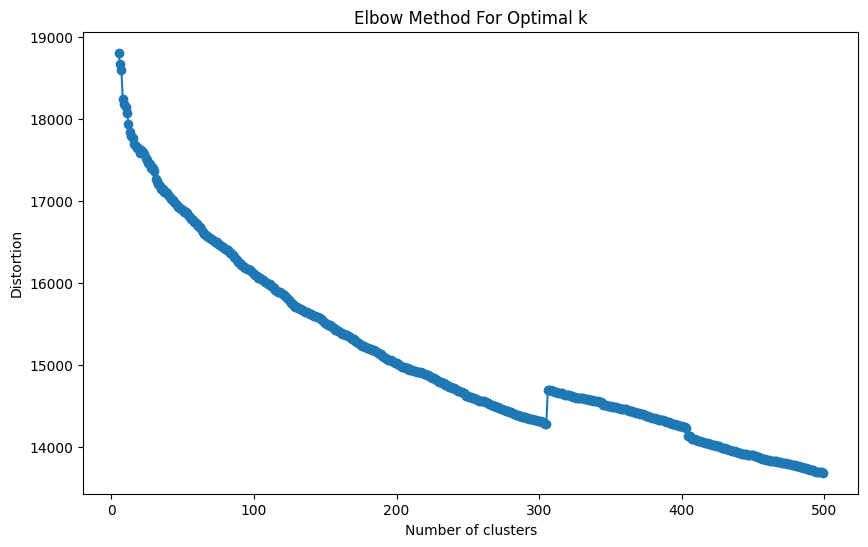

In [38]:
# affichage du graphique de l'Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, distortions, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

In [39]:

# nous allons partir sur 300 clusters, car c'est le point où la courbe commence à se stabiliser (le "coude" de la courbe).   
kmeans = KMeans(n_clusters=300, random_state=42)
kmeans.fit(tfidf_matrix_cl)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",300
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [40]:
def recommander_films_cluster(movie_id, num_recommendations=50):
    idx = indices[movie_id]
    titre_film = titre_vers_id[titre_vers_id == movie_id].index[0]

    cluster_label = kmeans.labels_[idx]
    indices_cluster = np.where(kmeans.labels_ == cluster_label)[0]
    indices_cluster = indices_cluster[indices_cluster != idx]
    top_indices = indices_cluster[:num_recommendations]

    res = [(tagsMovie.iloc[i]['title'], kmeans.labels_[i]) for i in top_indices]

    return tabulate(res, headers=["Titre", "Cluster"], tablefmt="pretty")

# Affichage des recommandations
movie_id = rechercher_par_titre(exple_titre)

if isinstance(movie_id, (int, np.integer)):
    print(f"Recommandations cluster pour {exple_titre} (movieId={movie_id}) :\n")
    print(recommander_films_cluster(movie_id))
else:
    print(f"Aucun film trouvé pour '{exple_titre}'")

Recommandations cluster pour Matrix, The (1999) (movieId=2571) :

+------------------------------------------------------------------+---------+
|                              Titre                               | Cluster |
+------------------------------------------------------------------+---------+
|                       Strange Days (1995)                        |   299   |
|                    Lawnmower Man, The (1992)                     |   299   |
|                       Sliding Doors (1998)                       |   299   |
|                           Tron (1982)                            |   299   |
|                         eXistenZ (1999)                          |   299   |
|                   Thirteenth Floor, The (1999)                   |   299   |
|                 Run Lola Run (Lola rennt) (1998)                 |   299   |
|                        Me Myself I (2000)                        |   299   |
|                        Flatliners (1990)                       

Modèle 4 : cluster sur la base des genome tags

In [53]:
# créons un dataframe qui contient les genome tags, en mettant movieId comme index
mv_genome = genomeMovie.set_index('movieId')
mv_genome = mv_genome[['tag']]

display(mv_genome.head())
tfidf_cl_genome = TfidfVectorizer()
tfidf_matrix_cl_genome = tfidf_cl_genome.fit_transform(mv_genome['tag'])


,tag
movieId,
1,talking animals destiny sentimental fairy tale...
2,happy ending predictable runaway good action d...
3,silly family pg-13 chase good mentor fish roma...
4,love story friendship divorce feel good movie ...
5,goofy culture clash cute! mentor crappy sequel...


In [54]:
# recherche du k optimal pour le clustering KMeans
range_n_clusters_gn = range(5, 300)
distortions_gn = []
for n_clusters in range_n_clusters_gn:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(tfidf_matrix_cl_genome)
    distortions_gn.append(kmeans.inertia_)  # inertia_ fonctionne sur les matrices sparse
    print(f"Distortion for {n_clusters} clusters: {distortions_gn[-1]:.4f}")

Distortion for 5 clusters: 8593.3987
Distortion for 6 clusters: 8490.4737
Distortion for 7 clusters: 8376.8441
Distortion for 8 clusters: 8281.2475
Distortion for 9 clusters: 8200.4341
Distortion for 10 clusters: 8083.7575
Distortion for 11 clusters: 8033.5433
Distortion for 12 clusters: 7932.1267
Distortion for 13 clusters: 7886.9155
Distortion for 14 clusters: 7831.4029
Distortion for 15 clusters: 7769.5920
Distortion for 16 clusters: 7729.0550
Distortion for 17 clusters: 7696.4991
Distortion for 18 clusters: 7668.8017
Distortion for 19 clusters: 7610.5274
Distortion for 20 clusters: 7560.0875
Distortion for 21 clusters: 7467.2102
Distortion for 22 clusters: 7430.7334
Distortion for 23 clusters: 7409.8744
Distortion for 24 clusters: 7390.0602
Distortion for 25 clusters: 7365.0583
Distortion for 26 clusters: 7334.6959
Distortion for 27 clusters: 7310.8049
Distortion for 28 clusters: 7281.5189
Distortion for 29 clusters: 7275.1368
Distortion for 30 clusters: 7252.2781
Distortion for 31

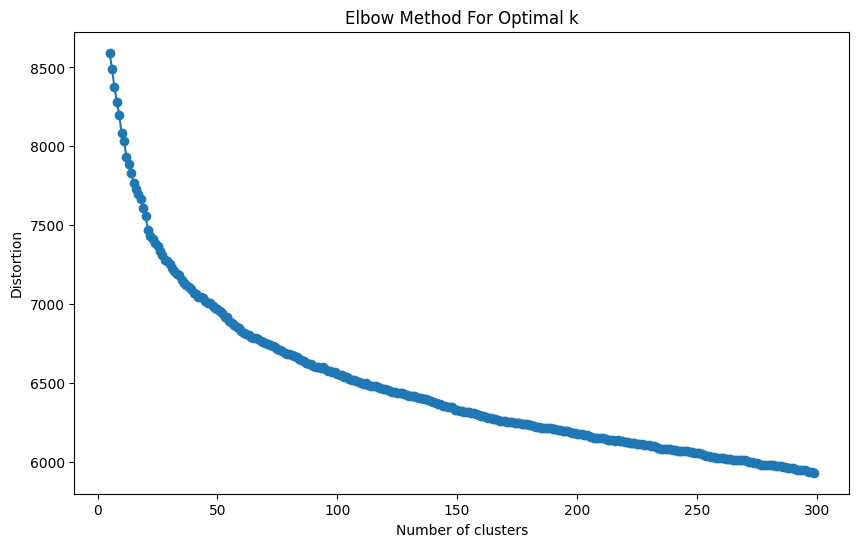

In [55]:
# affichage du graphique de l'Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters_gn, distortions_gn, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

In [56]:
kmeans_gn = KMeans(n_clusters=150, random_state=42)
kmeans_gn.fit(tfidf_matrix_cl_genome)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",150
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [57]:
def recommander_films_cluster_gn(movie_id, num_recommendations=50):
    idx = indices_genome[movie_id]
    titre_film = titre_vers_id[titre_vers_id == movie_id].index[0]

    cluster_label = kmeans_gn.labels_[idx]
    indices_cluster = np.where(kmeans_gn.labels_ == cluster_label)[0]
    indices_cluster = indices_cluster[indices_cluster != idx]
    top_indices = indices_cluster[:num_recommendations]

    res = [(genomeMovie.iloc[i]['title'], kmeans_gn.labels_[i]) for i in top_indices]

    return tabulate(res, headers=["Titre", "Cluster"], tablefmt="pretty")

# Affichage des recommandations
movie_id = rechercher_par_titre(exple_titre)

if isinstance(movie_id, (int, np.integer)):
    print(f"Recommandations cluster pour {exple_titre} (movieId={movie_id}) :\n")
    print(recommander_films_cluster_gn(movie_id))
else:
    print(f"Aucun film trouvé pour '{exple_titre}'")

Recommandations cluster pour Matrix, The (1999) (movieId=2571) :

+--------------------------------------------------------------------------------+---------+
|                                     Titre                                      | Cluster |
+--------------------------------------------------------------------------------+---------+
|                   Star Wars: Episode IV - A New Hope (1977)                    |   113   |
|                              Jurassic Park (1993)                              |   113   |
|                       Terminator 2: Judgment Day (1991)                        |   113   |
|                                 Twister (1996)                                 |   113   |
|                      Independence Day (a.k.a. ID4) (1996)                      |   113   |
|                                Die Hard (1988)                                 |   113   |
|                       E.T. the Extra-Terrestrial (1982)                        |   113   |
|   